## Do PCA on example session and plot trajectories over course of the trial

In [1]:
import os
import sys
import importlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats
import seaborn as sns

# pyaldata
sys.path.append("/home/zms24/Desktop") 
import PyalData.pyaldata as pyal # type:ignore

# tools functions
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from tools.dsp.preprocessing import preprocess

np.random.seed(0)
# imports for PCA
from sklearn.decomposition import PCA


In [2]:
solenoid_angles = {0: 60, 1: 120, 2: 240, 3: 300, 4: 0, 5: 60, 6: 120, 7: 180, 8: 240, 9: 300, 10: 0, 11: 180}

### Load in M044 data

In [3]:
def preprocess_m061(solenoid_remapping):
    
    ### First session ###
    data_dir = "/data/raw/M061/M061_2025_03_04_10_00"
    mat_file_0= "M061_2025_03_04_10_00_pyaldata_0.mat"
    mat_file_1= "M061_2025_03_04_10_00_pyaldata_1.mat"
    mat_file_2= "M061_2025_03_04_10_00_pyaldata_2.mat"

    fname0 = os.path.join(data_dir, mat_file_0)
    fname1 = os.path.join(data_dir, mat_file_1)
    fname2 = os.path.join(data_dir, mat_file_2)

    df0 = pyal.mat2dataframe(fname0, shift_idx_fields=True)
    df1 = pyal.mat2dataframe(fname1, shift_idx_fields=True)
    df2 = pyal.mat2dataframe(fname2, shift_idx_fields=True)
    df = pd.concat([df0, df1, df2], ignore_index=True)
    df = df.drop(columns="all_spikes") # the content is incorrect

    df_ = preprocess(df, only_trials=True)
    bin_size = df_['bin_size'][0]
    
    df_ = pyal.merge_signals(df_, [ "MOp_rates", "SSp_ul_rates", "CP_rates", "Thal_rates"], "all_rates")
    df_['trial_length'] = (df_['trial_length'] / (bin_size * 100)).astype(int)
    df_ = df_[df_['trial_length'] == 200]
    df_ = df_.drop(columns=["MOp_spikes", "SSp_ul_spikes", "CP_spikes", "Thal_spikes"]) # not needed anymore

    session_id = mat_file_0.replace("_pyaldata_0.mat", "")
    mouse = session_id.split('_')[0]
    perturb_time_idx = df_.idx_sol_on[0]
    # Remap solenoid angle values
    df_["solenoid_angle"] = df_["values_Sol_direction"].map(solenoid_remapping)
    sol_angles = sorted(df_.solenoid_angle.unique())
    areas =[ "MOp_rates", "SSp_ul_rates", "CP_rates", "Thal_rates", "all_rates"]

    session0_m061 = {'data': df_,
                 'brain_areas': areas,
                 'session_id': session_id,
                 'mouse': mouse,
                 'bin_size': bin_size,
                 'perturb_time_idx': perturb_time_idx,
                 'categories': sol_angles
                 }

    return session0_m061

In [4]:
M061_data = preprocess_m061(solenoid_angles)

field values_before_camera_trigger could not be converted to int.
field idx_before_camera_trigger could not be converted to int.
array field SSp_ul_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field Thal_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
field idx_motion could not be converted to int.
array field SSp_ul_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field Thal_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
field values_Sol_direction could not be converted to int.
field idx_Sol_direction could not be converted to int.
field values_Sol_duration could not be converted to int.
field idx_Sol_duration could not be converted to int.
field idx_sol_on could not be converted to 

/home/zms24/Desktop/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/home/zms24/Desktop/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/home/zms24/Desktop/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/home/zms24/Desktop/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(


Combined every 3 bins
Resulting SSp_ul_spikes ephys data shape is (NxT): (59, 200)
Resulting Thal_spikes ephys data shape is (NxT): (240, 200)
Resulting MOp_spikes ephys data shape is (NxT): (206, 200)
Resulting CP_spikes ephys data shape is (NxT): (356, 200)


In [5]:
def plot_solenoid_angle_distribution(df_):
    angles_deg = df_['solenoid_angle'].dropna().values
    angles_rad = np.deg2rad(angles_deg)  # Convert to radians for polar plot

    # Count occurrences of each unique angle
    unique_angles, counts = np.unique(angles_rad, return_counts=True)
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(2, 2), dpi =300)
    # fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
    bars = ax.bar(unique_angles, counts, width=np.deg2rad(50), color='skyblue', edgecolor='black')
    # ax.set_yticklabels([])
    # ax.set_title('Solenoid Angle Distribution', va='bottom')
    plt.show()

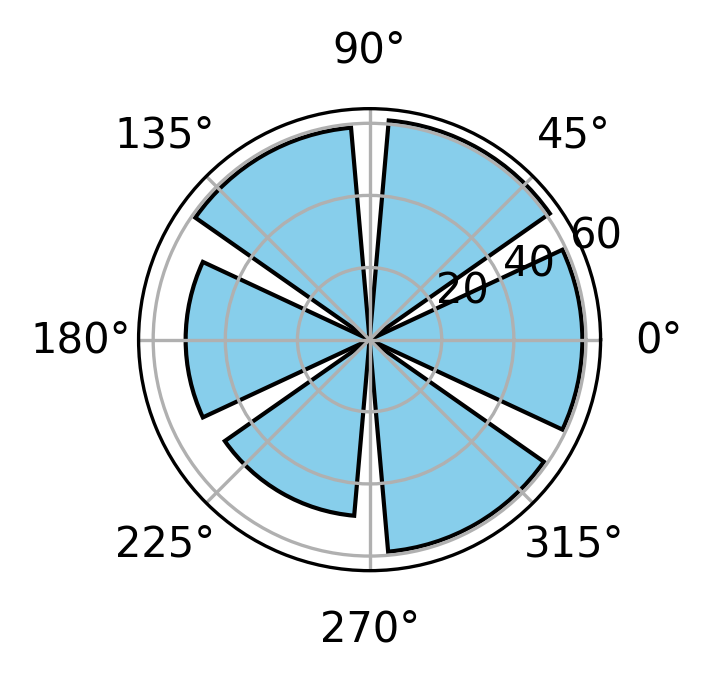

In [6]:
plot_solenoid_angle_distribution(M061_data['data'])

In [37]:
def compute_and_plot_pca(data, brain_area="CP", n_components=3):
    """
    Compute PCA on trials from a given brain area,
    average trajectories per solenoid angle,
    and plot them with start, end, and perturb markers.
    
    Args:
        data: dict with keys:
            - "data" : DataFrame with one row per trial
            - "brain_areas": list of brain area names
            - "categories": list of solenoid angles
            - "perturb_time_idx": int (time index of perturbation)
        brain_area: which brain area to use ("CP" by default)
        n_components: number of PCs (default 3)
    """

    # --- 1) Extract CP data ---
    df = data["data"]
    area_idx = data["brain_areas"].index(brain_area)
    all_trials = df[brain_area]  # each trial is (time, neurons)

    # --- 2) Concatenate all trials and run PCA ---
    concat = np.vstack(all_trials.to_numpy())
    pca = PCA(n_components=n_components)
    concat_pcs = pca.fit_transform(concat)

    # --- 3) Split back into trials ---
    lengths = [trial.shape[0] for trial in all_trials]
    split_pcs, idx = [], 0
    for L in lengths:
        split_pcs.append(concat_pcs[idx:idx+L])
        idx += L

    # --- 4) Group trials by solenoid angle ---
    angles = data["categories"]
    grouped = {ang: [] for ang in angles}
    for pcs, ang in zip(split_pcs, df.solenoid_angle):
        grouped[ang].append(pcs)

    # --- 5) Average trajectory per angle ---
    avg_traj = {ang: np.mean(np.stack(trials), axis=0)
                for ang, trials in grouped.items() if trials}

    # --- 6) Plot ---
    fig = plt.figure(figsize=(3,3), dpi=300)
    ax = fig.add_subplot(111, projection="3d")
    colors = plt.cm.Purples(np.linspace(0.2, 1, len(angles)))

    for (ang, traj), col in zip(avg_traj.items(), colors):
        ax.plot(traj[:,0], traj[:,1], traj[:,2], color=col, label=f"Angle {ang}°")
        ax.scatter(traj[0,0], traj[0,1], traj[0,2], color='black', marker="o", s=5)   # start
        ax.scatter(traj[-1,0], traj[-1,1], traj[-1,2], color='black', marker="x", s=5) # end
        pt = data["perturb_time_idx"]
        if pt < traj.shape[0]:
            ax.scatter(traj[pt,0], traj[pt,1], traj[pt,2], color=col, marker="*", s=30, edgecolor="red")

    # Add axis labels
    # ax.set_xlabel("PC1", fontsize=12)
    # ax.set_ylabel("PC2", fontsize=12)
    # ax.set_zlabel("PC3", fontsize=12)
    ax.set_title(f"PCA Trajectories - {brain_area}")
    ax.legend(bbox_to_anchor=(1.1,0.7), frameon= False)
    ax.view_init(elev=30, azim=30, roll=0)

    # Make background panes white (blank)
    ax.xaxis.pane.set_facecolor('white')
    ax.yaxis.pane.set_facecolor('white')
    ax.zaxis.pane.set_facecolor('white')

    # Remove gridlines
    ax.grid(False)

    # Hide 3D "pane edges"
    ax.xaxis.pane.set_edgecolor('white')
    ax.yaxis.pane.set_edgecolor('white')
    ax.zaxis.pane.set_edgecolor('white')
    plt.tight_layout()
    plt.show()

    return avg_traj, pca.explained_variance_ratio_


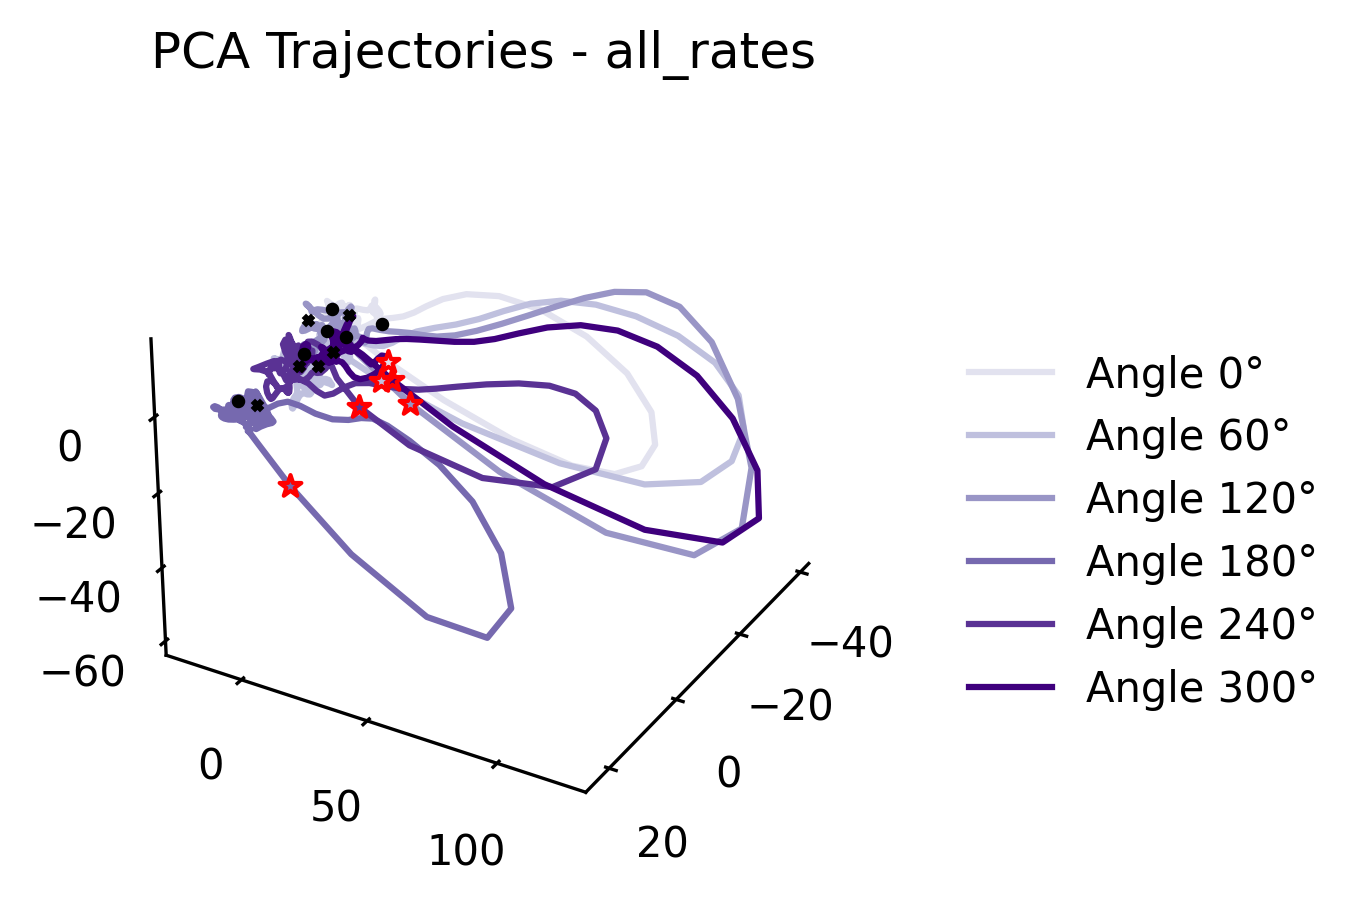

In [38]:
avg_traj, var_expl = compute_and_plot_pca(M061_data, brain_area="all_rates")